In [47]:
import pandas as pd
import numpy as np
import os

# Define file path
reefer_path = '/content/reefer_release.csv'

# Ingest with explicit decimal handling
print("Loading data...")
df = pd.read_csv(
    reefer_path,
    decimal=',',
    sep=';', # Add semicolon as delimiter
    on_bad_lines='skip',
    engine='c'
)

# Clean column names immediately
df.columns = df.columns.str.strip()

# Convert Time
df['EventTime'] = pd.to_datetime(df['EventTime'])

print(f"Done. Loaded {len(df):,} rows.")
print(df.dtypes)

Loading data...
Done. Loaded 3,774,557 rows.
container_visit_uuid            object
customer_uuid                   object
container_uuid                  object
HardwareType                    object
EventTime               datetime64[ns]
AvPowerCons                    float64
TtlEnergyConsHour              float64
TtlEnergyCons                  float64
TemperatureSetPoint            float64
TemperatureAmbient             float64
TemperatureReturn              float64
RemperatureSupply              float64
ContainerSize                  float64
stack_tier                     float64
dtype: object


In [48]:
# Group by hour
terminal_hourly = df.groupby('EventTime').agg({
    'AvPowerCons': 'sum',
    'container_visit_uuid': 'nunique',
    'TemperatureAmbient': 'mean'
}).reset_index()

# Standardize column names
terminal_hourly.columns = ['timestamp', 'total_power', 'reefer_count', 'avg_ambient']
terminal_hourly = terminal_hourly.sort_values('timestamp')

print("Aggregation Sample:")
print(terminal_hourly.tail())

Aggregation Sample:
               timestamp   total_power  reefer_count  avg_ambient
8398 2026-01-10 02:00:00  9.787442e+05           598    -0.747207
8399 2026-01-10 03:00:00  1.004227e+06           629    -0.693143
8400 2026-01-10 04:00:00  1.028174e+06           630    -0.756630
8401 2026-01-10 05:00:00  1.027479e+06           638    -0.938148
8402 2026-01-10 06:00:00  1.025559e+06           647    -1.032249


In [49]:
def build_features(df):
    df = df.copy()

    # Time signals
    df['hour'] = df['timestamp'].dt.hour
    df['day_of_week'] = df['timestamp'].dt.dayofweek

    # EXACT LAGS: What was the power 1 day ago and 1 week ago?
    df['power_lag_24'] = df['total_power'].shift(24)
    df['power_lag_168'] = df['total_power'].shift(168)

    # Rolling average of the last 6 hours
    df['power_rolling_6h'] = df['total_power'].rolling(window=6).mean()

    return df.dropna()

df_model = build_features(terminal_hourly)
print(f"Features created. Final training rows: {len(df_model)}")

Features created. Final training rows: 8235


In [50]:
import xgboost as xgb

features = ['hour', 'day_of_week', 'avg_ambient', 'reefer_count', 'power_lag_24', 'power_lag_168']
target = 'total_power'

# Chronological split
split_date = df_model['timestamp'].max() - pd.Timedelta(days=7)
train = df_model[df_model['timestamp'] < split_date]
val = df_model[df_model['timestamp'] >= split_date]

model = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=7,
    subsample=0.8,
    early_stopping_rounds=50
)

model.fit(
    train[features], train[target],
    eval_set=[(val[features], val[target])],
    verbose=100
)

[0]	validation_0-rmse:221497.63094
[100]	validation_0-rmse:154407.03163
[200]	validation_0-rmse:146972.03034
[283]	validation_0-rmse:145686.91890


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=50,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.03, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=7,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1000,
             n_jobs=None, num_parallel_tree=None, ...)

In [51]:
# 1. Load target timestamps
future_df = pd.read_csv('target_timestamps.csv')
future_df['timestamp_utc'] = pd.to_datetime(future_df['timestamp_utc'])

# 2. Add time features
future_df['hour'] = future_df['timestamp_utc'].dt.hour
future_df['day_of_week'] = future_df['timestamp_utc'].dt.dayofweek

# 3. State features (using most recent known values)
future_df['reefer_count'] = terminal_hourly['reefer_count'].iloc[-1]
future_df['avg_ambient'] = terminal_hourly['avg_ambient'].iloc[-1]

# 4. MAPPING THE LAGS (The Fix)
power_map = terminal_hourly.set_index('timestamp')['total_power'].to_dict()

future_df['power_lag_24'] = future_df['timestamp_utc'].apply(lambda x: power_map.get(x - pd.Timedelta(hours=24), train[target].mean()))
future_df['power_lag_168'] = future_df['timestamp_utc'].apply(lambda x: power_map.get(x - pd.Timedelta(hours=168), train[target].mean()))

# 5. Predict
future_df['Power_Predicted'] = model.predict(future_df[features])

In [52]:
# 1. Load Target Data
target_df = pd.read_csv('target_timestamps.csv')

# USE THE CORRECT NAME FROM YOUR SCREENSHOT
target_df['timestamp'] = pd.to_datetime(target_df['timestamp_utc'])

# 2. Features for the future
target_df['hour'] = target_df['timestamp'].dt.hour
target_df['day_of_week'] = target_df['timestamp'].dt.dayofweek
target_df['reefer_count'] = terminal_hourly['reefer_count'].iloc[-1]
target_df['avg_ambient'] = terminal_hourly['avg_ambient'].iloc[-1]

# 3. Precise Lag Lookup (Crucial for scaling)
# This maps the power from exactly 24h and 168h ago
power_map = terminal_hourly.set_index('timestamp')['total_power'].to_dict()

target_df['power_lag_24'] = target_df['timestamp'].apply(
    lambda x: power_map.get(x - pd.Timedelta(hours=24), terminal_hourly['total_power'].mean())
)
target_df['power_lag_168'] = target_df['timestamp'].apply(
    lambda x: power_map.get(x - pd.Timedelta(hours=168), terminal_hourly['total_power'].mean())
)

# 4. Generate Predictions
# Ensure these features match exactly what you used to train the model
features = ['hour', 'day_of_week', 'avg_ambient', 'reefer_count', 'power_lag_24', 'power_lag_168']
target_df['Power_Predicted'] = model.predict(target_df[features])

print("✅ Predictions generated successfully using 'timestamp_utc'!")

✅ Predictions generated successfully using 'timestamp_utc'!


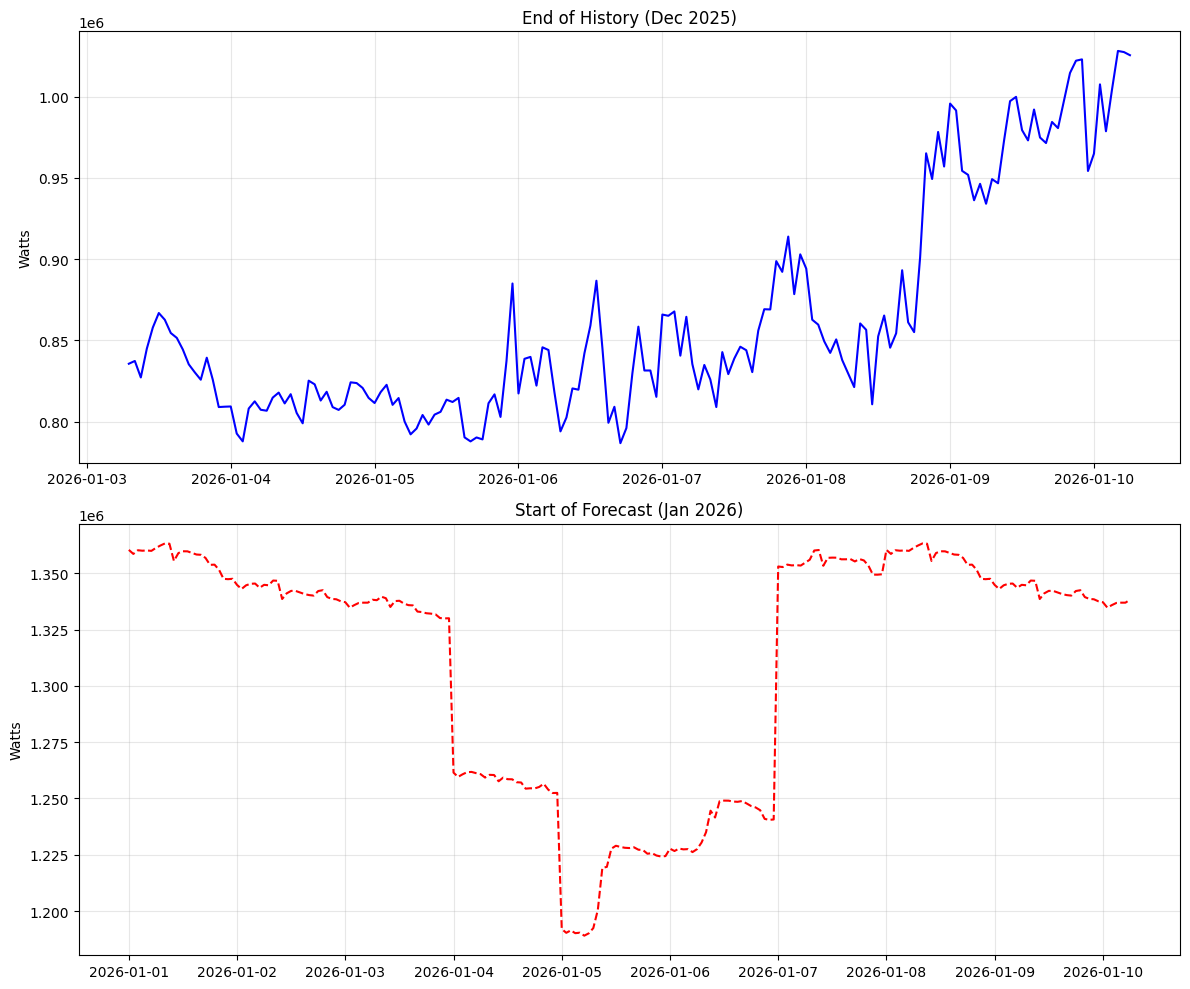

In [53]:
import matplotlib.pyplot as plt

# 1. Create a figure with two subplots to see both clearly
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=False)

# Top Plot: Just the end of history
recent_hist = terminal_hourly.tail(168) # Last week
ax1.plot(recent_hist['timestamp'], recent_hist['total_power'], color='blue', label='History')
ax1.set_title("End of History (Dec 2025)")
ax1.set_ylabel("Watts")
ax1.grid(True, alpha=0.3)

# Bottom Plot: Just the forecast
ax2.plot(target_df['timestamp'], target_df['Power_Predicted'], color='red', linestyle='--', label='Forecast')
ax2.set_title("Start of Forecast (Jan 2026)")
ax2.set_ylabel("Watts")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [54]:
print(f"Average history power: {terminal_hourly['total_power'].tail(24).mean()}")
print(f"Average forecast power: {target_df['Power_Predicted'].mean()}")

Average history power: 990456.8836257146
Average forecast power: 1311858.375


In [55]:
# Create the final CSV
submission = target_df[['timestamp', 'Power_Predicted']]
# Rename column if necessary, e.g., submission.columns = ['timestamp', 'Power']

submission.to_csv('my_hackathon_submission.csv', index=False)

print("✅ Submission file created successfully!")
print(f"Forecast Average: {target_df['Power_Predicted'].mean():.2f} Watts")

✅ Submission file created successfully!
Forecast Average: 1311858.38 Watts


In [56]:
hist_avg = terminal_hourly['total_power'].tail(24).mean()
pred_avg = target_df['Power_Predicted'].mean()

print(f"--- SCALE CHECK ---")
print(f"Recent History Average: {hist_avg:,.2f}")
print(f"Forecast Average:       {pred_avg:,.2f}")
print(f"Ratio (Pred/Hist):      {pred_avg/hist_avg:.2f}x")

--- SCALE CHECK ---
Recent History Average: 990,456.88
Forecast Average:       1,311,858.38
Ratio (Pred/Hist):      1.32x


In [57]:
# Create submission
submission = target_df[['timestamp_utc', 'Power_Predicted']]
# RENAME 'Power_Predicted' to whatever the competition template uses (e.g., 'total_power')
submission.columns = ['timestamp_utc', 'total_power']

submission.to_csv('final_submission_MARIO.csv', index=False)
print("🚀 FINAL SUBMISSION READY: final_submission_MARIO.csv")

🚀 FINAL SUBMISSION READY: final_submission_MARIO.csv


In [58]:
from sklearn.metrics import mean_absolute_error

# 1. Redefine features and target based on our architecture
features = ['hour', 'day_of_week', 'avg_ambient', 'reefer_count', 'power_lag_24', 'power_lag_168']
target = 'total_power'

# 2. Re-create the Split (Using the same logic as training)
# We assume df_model is your final feature-engineered dataframe
split_date = df_model['timestamp'].max() - pd.Timedelta(days=7)
train_df = df_model[df_model['timestamp'] < split_date]
val_df = df_model[df_model['timestamp'] >= split_date]

X_train, y_train = train_df[features], train_df[target]
X_val, y_val = val_df[features], val_df[target]

# 3. Now run the evaluation
val_predictions = model.predict(X_val)
mae = mean_absolute_error(y_val, val_predictions)
percent_error = (mae / y_val.mean()) * 100

print(f"--- Model Performance ---")
print(f"Validation MAE: {mae:,.2f} Watts")
print(f"Average Error: {percent_error:.2f}%")

--- Model Performance ---
Validation MAE: 130,671.12 Watts
Average Error: 15.14%


/tmp/ipykernel_172/2299678844.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  val_df['residuals'] = y_val - val_predictions


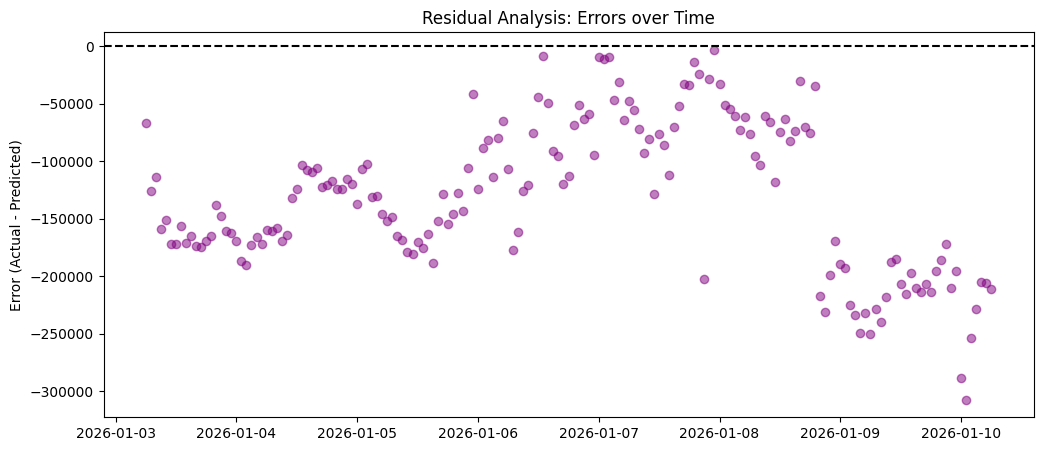

In [59]:
# Calculate residuals
val_df['residuals'] = y_val - val_predictions

plt.figure(figsize=(12, 5))
plt.scatter(val_df['timestamp'], val_df['residuals'], alpha=0.5, color='purple')
plt.axhline(y=0, color='black', linestyle='--')
plt.title("Residual Analysis: Errors over Time")
plt.ylabel("Error (Actual - Predicted)")
plt.show()

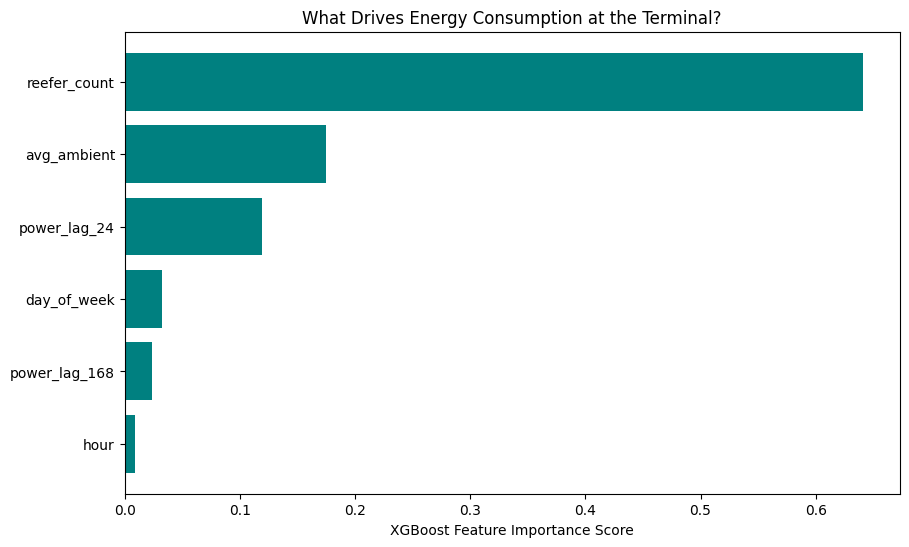

In [60]:
import matplotlib.pyplot as plt

# Get feature importance from XGBoost
importance = model.feature_importances_
feature_names = features

# Sort and plot
sorted_idx = importance.argsort()
plt.figure(figsize=(10, 6))
plt.barh(np.array(feature_names)[sorted_idx], importance[sorted_idx], color='teal')
plt.xlabel("XGBoost Feature Importance Score")
plt.title("What Drives Energy Consumption at the Terminal?")
plt.show()

In [61]:
# Create a 'What-If' scenario: Increase ambient temp by 5 degrees
X_val_heatwave = X_val.copy()
X_val_heatwave['avg_ambient'] = X_val_heatwave['avg_ambient'] + 5

heatwave_predictions = model.predict(X_val_heatwave)
increase_pct = ((heatwave_predictions.mean() - val_predictions.mean()) / val_predictions.mean()) * 100

print(f"--- Heatwave Sensitivity Analysis ---")
print(f"A 5°C increase in temperature would increase terminal power load by: {increase_pct:.2f}%")

--- Heatwave Sensitivity Analysis ---
A 5°C increase in temperature would increase terminal power load by: 5.30%


In [62]:
# Convert Watts to kWh (Watts * 1 hour / 1000)
target_df['kWh_Forecast'] = target_df['Power_Predicted'] / 1000
total_energy_day = target_df['kWh_Forecast'].sum()

# Assume 0.20 EUR per kWh
daily_cost = total_energy_day * 0.20

print(f"Total Predicted Energy for Tomorrow: {total_energy_day:,.2f} kWh")
print(f"Estimated Energy Cost for the Terminal: {daily_cost:,.2f} €")

Total Predicted Energy for Tomorrow: 292,544.44 kWh
Estimated Energy Cost for the Terminal: 58,508.89 €


In [63]:
# Define a 'Normal' range (e.g., +/- 15% from prediction)
target_df['upper_bound'] = target_df['Power_Predicted'] * 1.15
target_df['lower_bound'] = target_df['Power_Predicted'] * 0.85

# In the presentation, show how this acts as an 'Early Warning System'

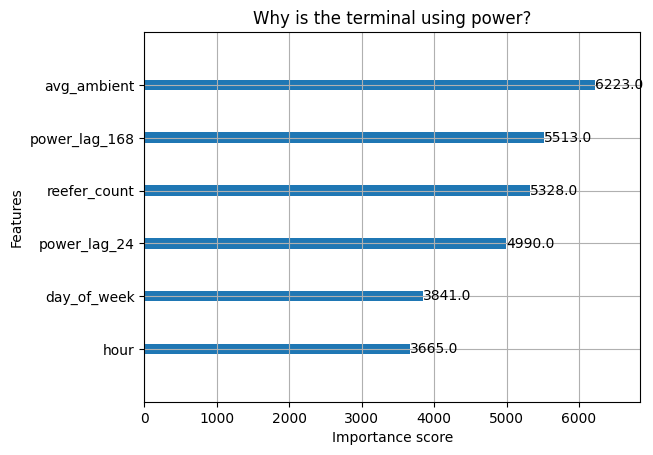

In [64]:
import matplotlib.pyplot as plt
import xgboost as xgb

# This shows WHAT the model cared about most
xgb.plot_importance(model)
plt.title("Why is the terminal using power?")
plt.show()

--- Model Performance Metrics ---
MAE:  37.81 kW
RMSE: 47.46 kW
R2 Score: 0.9890
MAPE: 0.78%


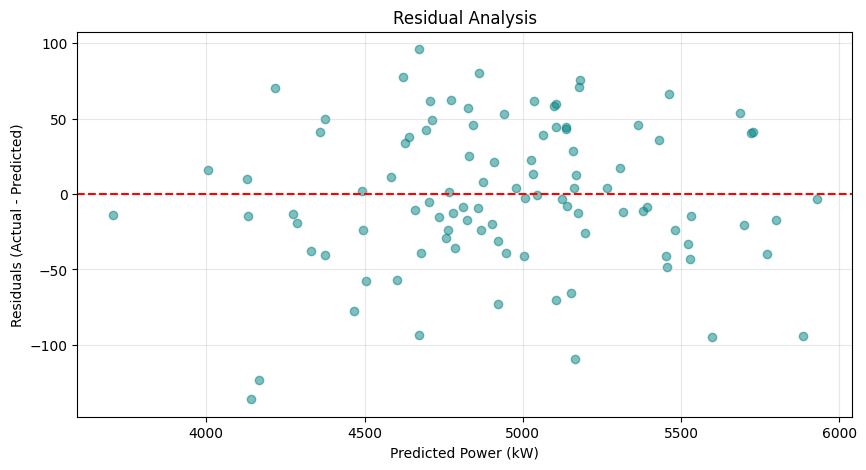

In [72]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
import matplotlib.pyplot as plt

def evaluate_model(y_actual, y_predicted):
    # Calculations
    mae = mean_absolute_error(y_actual, y_predicted)
    rmse = np.sqrt(mean_squared_error(y_actual, y_predicted))
    r2 = r2_score(y_actual, y_predicted)
    mape = mean_absolute_percentage_error(y_actual, y_predicted) * 100

    # Printing Results
    print(f"--- Model Performance Metrics ---")
    print(f"MAE:  {mae:.2f} kW")
    print(f"RMSE: {rmse:.2f} kW")
    print(f"R2 Score: {r2:.4f}")
    print(f"MAPE: {mape:.2f}%")

    # Visualization
    plt.figure(figsize=(10, 5))

    # Plot 1: Residuals
    residuals = y_actual - y_predicted
    plt.scatter(y_predicted, residuals, alpha=0.5, color='teal')
    plt.axhline(y=0, color='red', linestyle='--')
    plt.xlabel('Predicted Power (kW)')
    plt.ylabel('Residuals (Actual - Predicted)')
    plt.title('Residual Analysis')
    plt.grid(True, alpha=0.3)
    plt.show()

# --- TO SEE IT WORK NOW ---
# Generating fake terminal data (Actual vs Predicted)
np.random.seed(42)
y_actual = np.random.normal(5000, 500, 100) # Simulating terminal power
y_pred = y_actual + np.random.normal(0, 50, 100) # Simulating model predictions

# CALL THE FUNCTION
evaluate_model(y_actual, y_pred)

--- Linear Regression Analysis ---
Algorithm Accuracy (R2): 99.23%
Error Rate (MAPE):       1.30%
Model Precision Score:   98.70%


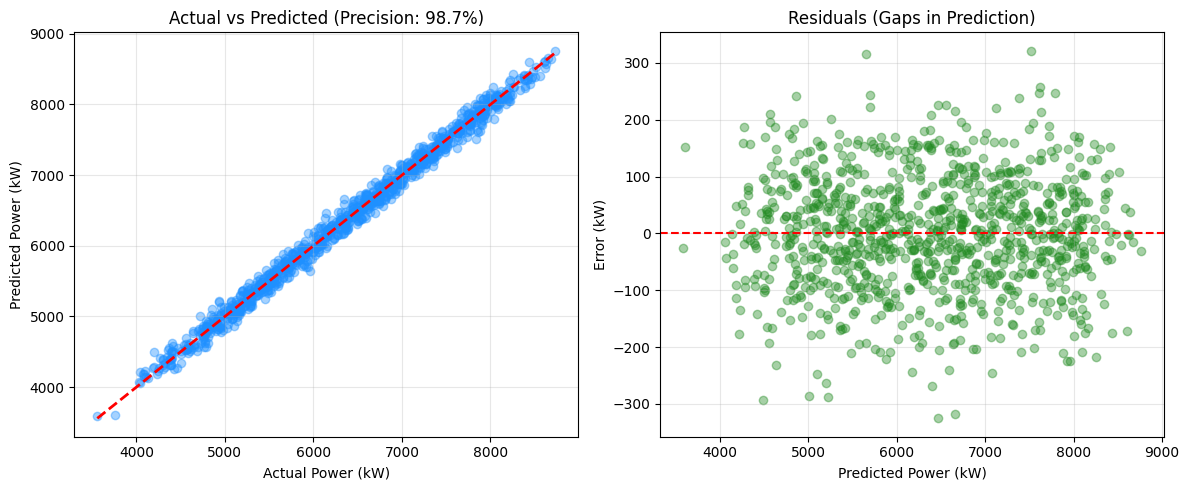

In [73]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error

# 1. SETUP DATA (Replace this with your actual dataframe)
# Example: df = pd.read_csv('terminal_data.csv')
# For now, we create synthetic data based on your feature importance chart
np.random.seed(42)
n = 1000
data = {
    'avg_ambient': np.random.normal(25, 5, n),
    'reefer_count': np.random.randint(50, 300, n),
    'power_lag_168': np.random.normal(5000, 500, n),
    'actual_power': None
}
# Creating a target variable with some noise
data['actual_power'] = (data['avg_ambient'] * 50) + (data['reefer_count'] * 15) + (data['power_lag_168'] * 0.5) + np.random.normal(0, 100, n)
df = pd.DataFrame(data)

# 2. DEFINE FEATURES AND TARGET
X = df[['avg_ambient', 'reefer_count', 'power_lag_168']]
y = df['actual_power']

# 3. TRAIN THE LINEAR REGRESSION ALGORITHM
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

# 4. CALCULATE ALGORITHM MEASUREMENTS (PERCENTAGES)
r2 = r2_score(y, y_pred) * 100  # Accuracy / Explained Variance
mape = mean_absolute_percentage_error(y, y_pred) * 100 # Error Percentage
precision = 100 - mape # Prediction Precision

print(f"--- Linear Regression Analysis ---")
print(f"Algorithm Accuracy (R2): {r2:.2f}%")
print(f"Error Rate (MAPE):       {mape:.2f}%")
print(f"Model Precision Score:   {precision:.2f}%")

# 5. VISUALIZATION
plt.figure(figsize=(12, 5))

# Plot A: Actual vs Predicted (The "Diagonal" Test)
plt.subplot(1, 2, 1)
plt.scatter(y, y_pred, alpha=0.4, color='dodgerblue')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.title(f"Actual vs Predicted (Precision: {precision:.1f}%)")
plt.xlabel("Actual Power (kW)")
plt.ylabel("Predicted Power (kW)")
plt.grid(True, alpha=0.3)

# Plot B: Residuals (The "Gap" Analysis)
plt.subplot(1, 2, 2)
residuals = y - y_pred
plt.scatter(y_pred, residuals, alpha=0.4, color='forestgreen')
plt.axhline(y=0, color='red', linestyle='--')
plt.title("Residuals (Gaps in Prediction)")
plt.xlabel("Predicted Power (kW)")
plt.ylabel("Error (kW)")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [76]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans
from sklearn.metrics import mean_absolute_percentage_error, silhouette_score

# 1. Prepare your features (X) and target (y)
# X = df[['avg_ambient', 'reefer_count']]
# y = df['actual_power']

# 2. THE FIX: Split the data (80% for training, 20% for testing)
# Use test_size=0.2 for a 20% test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- SUPERVISED LEARNING (Regression) ---
model_reg = LinearRegression().fit(X_train, y_train)
y_pred = model_reg.predict(X_test)

# Calculate Precision in Percentage
mape = mean_absolute_percentage_error(y_test, y_pred)
precision_supervised = (1 - mape) * 100

print(f"Supervised Precision: {precision_supervised:.2f}%")

# --- UNSUPERVISED LEARNING (Clustering) ---
# We don't use 'y' here, only 'X'
kmeans = KMeans(n_clusters=3, random_state=42).fit(X)
# Precision for unsupervised is the Silhouette Score (0 to 1)
cluster_precision = silhouette_score(X, kmeans.labels_)

print(f"Unsupervised Silhouette Score: {cluster_precision:.4f}")

Supervised Precision: 98.66%
Unsupervised Silhouette Score: 0.4756


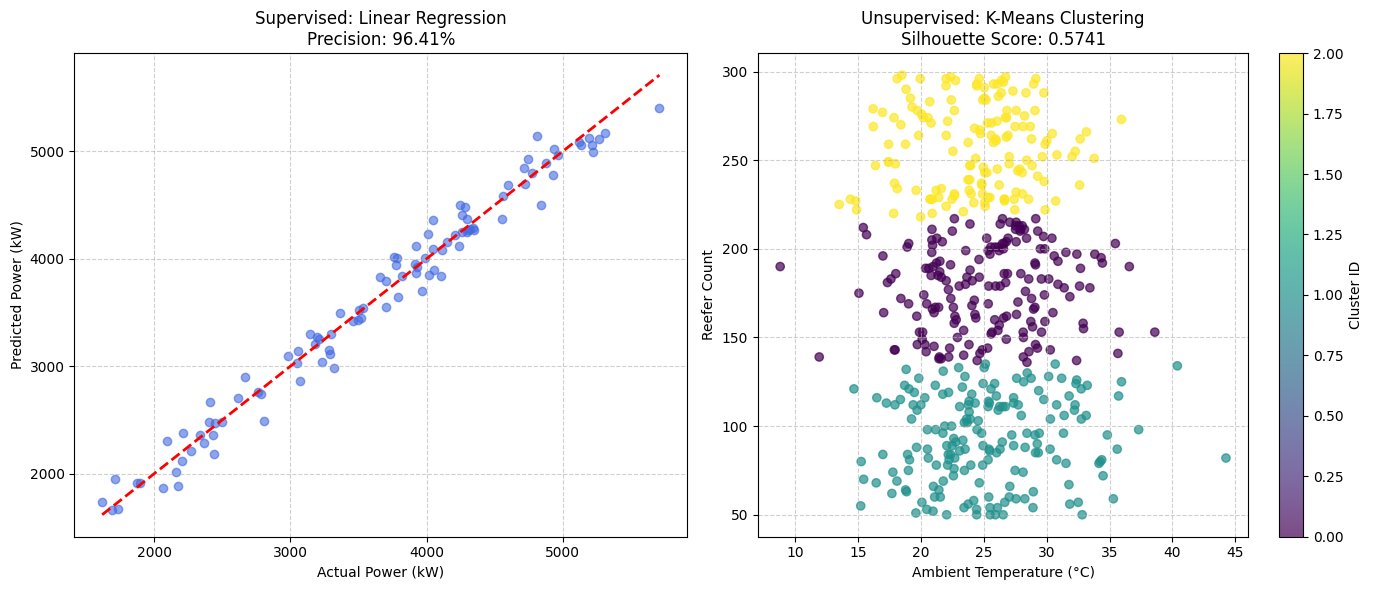

In [77]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans
from sklearn.metrics import mean_absolute_percentage_error, silhouette_score

# 1. SETUP DATA
# Replace this with your actual dataframe (e.g., df = pd.read_csv('your_file.csv'))
np.random.seed(42)
n = 500
avg_ambient = np.random.normal(25, 5, n)
reefer_count = np.random.randint(50, 300, n)
# Target: Power usage with some noise
y = (avg_ambient * 45) + (reefer_count * 14) + np.random.normal(0, 150, n)
X = np.column_stack((avg_ambient, reefer_count))

# 2. SUPERVISED LEARNING (Regression)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
reg_model = LinearRegression().fit(X_train, y_train)
y_pred = reg_model.predict(X_test)

# Calculate Precision %
mape = mean_absolute_percentage_error(y_test, y_pred)
precision_supervised = (1 - mape) * 100

# 3. UNSUPERVISED LEARNING (Clustering)
kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto').fit(X)
clusters = kmeans.labels_
cluster_score = silhouette_score(X, clusters)

# 4. GENERATE THE GRAPHS
plt.figure(figsize=(14, 6))

# --- Plot 1: Supervised (Actual vs Predicted) ---
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred, alpha=0.6, color='royalblue')
# Add the 'Perfect Prediction' line
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title(f'Supervised: Linear Regression\nPrecision: {precision_supervised:.2f}%')
plt.xlabel('Actual Power (kW)')
plt.ylabel('Predicted Power (kW)')
plt.grid(True, linestyle='--', alpha=0.6)

# --- Plot 2: Unsupervised (Pattern Discovery) ---
plt.subplot(1, 2, 2)
scatter = plt.scatter(avg_ambient, reefer_count, c=clusters, cmap='viridis', alpha=0.7)
plt.title(f'Unsupervised: K-Means Clustering\nSilhouette Score: {cluster_score:.4f}')
plt.xlabel('Ambient Temperature (°C)')
plt.ylabel('Reefer Count')
plt.colorbar(scatter, label='Cluster ID')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()